# AI-Based Voltage Estimation Tutorial | <font color=red>Part 1</font>: Keras-Based LV Voltage Estimation

## 1. Introduction

### Objectives

The objectives of this tutorial are:

1. To familiarise yourself with how power engineers can estimate **customer voltage magnitudes (V) from active power (P) and reactive power (Q)** in a low-voltage (LV) distribution network. You will use a **neural network**, a model that learns this relationship from examples. All power and voltage data are **simulated**, not measurements from real customers.

2. To become familiar with **Keras**, a Python tool for building and training neural networks. You will prepare the data, train a model and check its voltage estimates in a Jupyter notebook. Training means adjusting the model using examples. This tutorial is intended for **electrical engineering students in the Power specialization**; **no previous knowledge of neural networks is required**. New concepts are explained when they are needed.


### Structure of this Notebook

The rest of this notebook is divided into three parts:

- **2. Tutorial.**
    - You will learn, step by step, how to prepare simulated data and train a Keras model to estimate customer voltages.
    - You will learn how to compare model settings and check voltage estimates and errors on separate test data.
- **3. Exercises.** You will first modify a neural network and compare its validation errors, then train and test your selected voltage estimator.
- **4. Exercise Workspace.** Use the relevant tutorial code to complete each numbered task and display its results.

<font color='red'>**<u>Note</u>:**</font> Work through **2. Tutorial** before attempting the exercises. Make sure you understand which data are used to train the model, which are used to choose its settings, and which are reserved for the final check.


## 2. Tutorial

Follow the sections in order. Each step introduces the relevant code, the settings you can change and the output to inspect. Start with the **quick** training mode in Section 2.5.1.


### 2.1 Test LV Circuit and Considerations

The simulated LV feeder supplies **31 customers**. Its topology is shown in **Figure 1**. The upstream supply condition is fixed while customer power varies over time.

- All P, Q and V values are **simulation outputs**. This notebook loads prepared data; it does not run a new power-flow simulation.
- At each time step, all 31 customers' P/Q values are used to estimate their voltage magnitudes **at that same time**, not at a future time.
- Each row represents 5 minutes. Input columns are ordered `P1, Q1, ..., P31, Q31`; output columns are ordered `V1, ..., V31`.
- Training data are used to learn the relationship and choose model settings. Test data are kept for the final check. The topology provides context but is not an input to the neural network.


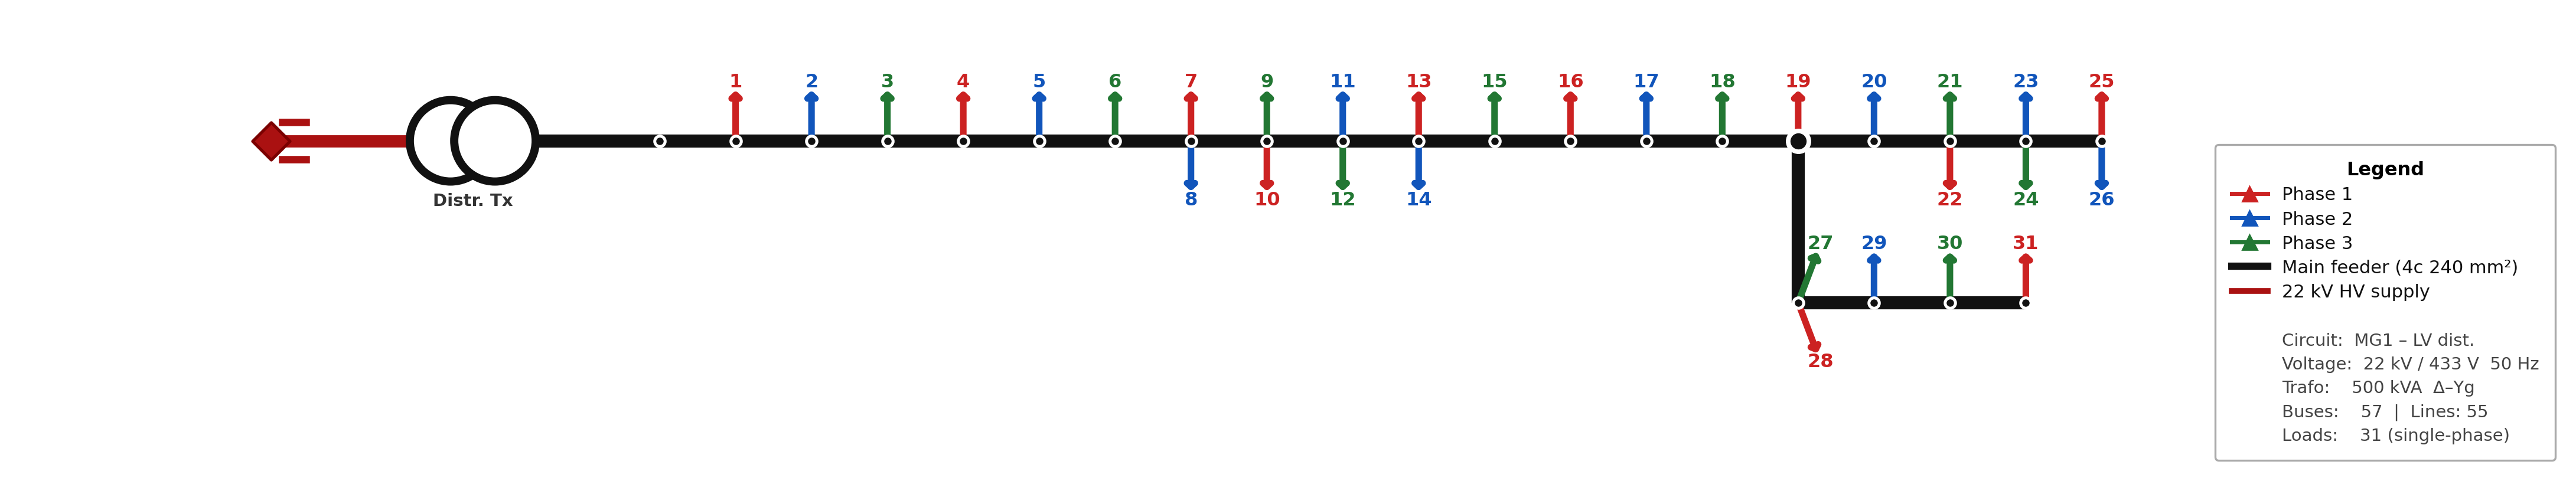


**<center>Figure 1. Simulated LV Circuit Topology</center>**


| Item | Value in the supplied dataset |
|---|---|
| Customers | 31 |
| Inputs per time step | 62 P/Q values |
| Outputs per time step | 31 voltage magnitudes |
| Sampling interval | 5 minutes |
| Training data | 6,048 rows (21 days) |
| Test data | 2,016 rows (7 days) |

<p align="center"><strong>Table 1. Data used for LV voltage estimation</strong></p>

`[P1, Q1, ..., P31, Q31]  →  neural network  →  [V1, ..., V31]`

Results apply to these simulated conditions. Accuracy on a different feeder or on real measurements would require a separate assessment.


### 2.2 Initialisation

Run the cells below in order. This notebook works both locally and in Google Colab.


#### 2.2.1 Import libraries

Start with **Prepare the runtime**, then run the import cell. **Keras** builds the neural network and **TensorFlow** performs its calculations. In Colab, the first cell installs the libraries; if a restart is requested, restart and run from that cell again.


In [1]:
#@title Prepare the runtime (run this cell)
import os
import sys
import subprocess
from pathlib import Path
import itertools
import time
import zipfile
import json

IN_COLAB = bool(os.getenv("COLAB_RELEASE_TAG") or os.getenv("COLAB_BACKEND_VERSION"))
if IN_COLAB:
    # Install the runtime libraries only; Jupyter itself is already provided.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "tensorflow>=2.16,<3", "keras>=3,<4", "numpy>=1.26",
        "pandas>=2.2", "scikit-learn>=1.4", "matplotlib>=3.8",
    ])

os.environ["KERAS_BACKEND"] = "tensorflow"  # Set before importing Keras.

# Hide framework startup diagnostics, not Python exceptions.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


In [2]:
import keras
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 12)
tf.get_logger().setLevel("ERROR")


The following cell prepares the tutorial files.

- **Local:** Locally, start in this tutorial folder or the project root; no ZIP upload is needed.
- **Colab:** use the upload button shown by this cell to select `Tutorial_1_Colab_Data.zip`. Do not rename or unpack it yourself.

<font color=red>Note:</font> Only use the supplied ZIP from a trusted source. A new Colab runtime requires another upload.


In [3]:
# Prepare the local working path or upload the Colab data package.
added_path = ""
if (Path.cwd() / "Tutorial_1_LV_Vol_Estimation").is_dir():
    added_path = "Tutorial_1_LV_Vol_Estimation"

if IN_COLAB:
    from google.colab import files

    added_path = "Tutorial_1"
    data_directory = Path.cwd() / added_path
    data_directory.mkdir(parents=True, exist_ok=True)
    archive_path = data_directory / "Tutorial_1_Colab_Data.zip"
    if not archive_path.is_file():
        files.upload(target_dir=str(data_directory))
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(data_directory)


#### 2.2.2 Set the working path

The default finds the tutorial from the project root or the tutorial folder.
If Jupyter starts elsewhere, replace the first assignment below with
`TUTORIAL_DIRECTORY = Path("your/tutorial/folder")` using a path relative to
the current working directory, or with an absolute path. The next line resolves
it once. Relative `DATA_FILES` entries in Section 2.3.1 are interpreted from
this resolved tutorial directory; absolute entries are used directly.


In [4]:
TUTORIAL_DIRECTORY = Path.cwd() / added_path  # Edit this assignment if needed.
TUTORIAL_DIRECTORY = TUTORIAL_DIRECTORY.expanduser().resolve()
if not TUTORIAL_DIRECTORY.is_dir():
    raise FileNotFoundError(
        f"Tutorial directory does not exist: {TUTORIAL_DIRECTORY}. "
        "Set TUTORIAL_DIRECTORY to the folder containing this tutorial."
    )

def resolve_file(path, label):
    candidate = Path(path).expanduser()
    if not candidate.is_absolute():
        candidate = TUTORIAL_DIRECTORY / candidate
    resolved = candidate.resolve()
    if not resolved.is_file():
        raise FileNotFoundError(
            f"Missing {label}: {resolved}. Check TUTORIAL_DIRECTORY and this file entry."
        )
    return resolved

print("Tutorial directory ready:", TUTORIAL_DIRECTORY.name)


#### 2.2.3 Set the random seed

The model starts with randomly chosen weights. A **random seed** helps repeat the same starting point and training-row order. The code sets the seed and reports the initial comparison seed; results can still vary across environments.


In [5]:
SEED = 42

def set_seed(seed=SEED):
    keras.utils.set_random_seed(seed)

set_seed()
print(f"Initial comparison seed: {SEED}")


Initial comparison seed: 42


### 2.3 Simulated Data Preparation

Here, **inputs** are the P/Q values supplied to the model. **Targets** are the corresponding simulated voltages it should learn to estimate.


#### 2.3.1 Set the individual data file paths

`DATA_FOLDER` selects the supplied data location. The four entries in `DATA_FILES` are the paths you can edit; **each may point to a different folder**.

| Entry | Contents | Use |
|---|---|---|
| `PQ_tr` | Training P/Q | Training and model selection inputs |
| `V_tr` | Training voltages | Training and model selection targets |
| `PQ_te` | Test P/Q | Final-check inputs |
| `V_te` | Test voltages | Final-check targets |

The loop checks one file at a time and prints its tutorial-relative path (or filename for an external file). All values are **simulated**. In Colab, use uploaded files rather than paths on your computer.

Relative file entries start at `TUTORIAL_DIRECTORY`; absolute entries are used directly. Do not prefix a relative entry with the tutorial folder a second time.


In [6]:
# Select the supplied data folder.
if IN_COLAB:
    DATA_FOLDER = Path("data")
else:
    DATA_FOLDER = Path("synthentic_data_5_min_LV")

# Edit individual entries here if your files are in different folders.
DATA_FILES = {
    "PQ_tr": DATA_FOLDER / "training/PQ.pkl",
    "V_tr": DATA_FOLDER / "training/V.pkl",
    "PQ_te": DATA_FOLDER / "test/PQ.pkl",
    "V_te": DATA_FOLDER / "test/V.pkl",
}

# Resolve each entry once; absolute paths are not prefixed.
data_files = {name: resolve_file(path, name) for name, path in DATA_FILES.items()}
for name, full_path in data_files.items():
    shown_path = (full_path.relative_to(TUTORIAL_DIRECTORY)
                  if full_path.is_relative_to(TUTORIAL_DIRECTORY)
                  else Path(full_path.name))
    print(f"{name}: {shown_path}")


PQ_tr: synthentic_data_5_min_LV\training\PQ.pkl
V_tr: synthentic_data_5_min_LV\training\V.pkl
PQ_te: synthentic_data_5_min_LV\test\PQ.pkl
V_te: synthentic_data_5_min_LV\test\V.pkl


#### 2.3.2 Import the training and test data

Read each file into a pandas table. `tr` means training, `te` means test, and `df` means DataFrame (a table).

The preview shows only three time steps for the first three customers; **the full data remain loaded**. Test data are kept for the final check, not for choosing model settings.


In [7]:
# Load the training inputs (P/Q) and their target voltages (V).
PQ_tr_df = pd.read_pickle(data_files["PQ_tr"])
V_tr_df = pd.read_pickle(data_files["V_tr"])

# Load the separate test inputs and target voltages for later use.
PQ_te_df = pd.read_pickle(data_files["PQ_te"])
V_te_df = pd.read_pickle(data_files["V_te"])

# iloc[row selection, column selection]: preview the first three customers.
print("First three training rows: P1, Q1, P2, Q2, P3, Q3")
display(PQ_tr_df.iloc[:3, :6])
print("Corresponding training voltages: V1, V2, V3")
display(V_tr_df.iloc[:3, :3])


First three training rows: P1, Q1, P2, Q2, P3, Q3


,0,1,2,3,4,5
0,0.120693,0.032818,0.649865,-0.296134,0.349897,0.169386
1,0.117263,0.028463,0.320885,0.139661,0.215703,0.038703
2,0.116715,-0.047785,0.822305,0.278458,0.354829,-0.133146


Corresponding training voltages: V1, V2, V3


,0,1,2
0,249.821308,249.888347,249.892601
1,249.899409,249.843989,249.866556
2,249.93567,249.821681,249.89114


#### 2.3.3 Check the data and prepare the arrays

Run the three steps below. An `assert` stops the code if a required condition is not met.

1. Check that the row and column labels match. P/Q and V must refer to the same time steps and customers; matching labels alone cannot prove that the original data were correctly paired.
2. Convert each table to a numeric `float32` array for Keras. This changes the storage format; **it does not normalise the values**.
3. Check the sizes and reject empty data, missing values or infinity.

`shape[0]` is the number of rows and `shape[1]` is the number of columns. Expect training shapes `(6048, 62)` and `(6048, 31)`, and test shapes `(2016, 62)` and `(2016, 31)`. There are 62 P/Q inputs and 31 voltage targets per time step.


In [8]:
# 1. Check that corresponding row and column labels match.
assert PQ_tr_df.index.equals(V_tr_df.index), "Training row labels differ."
assert PQ_te_df.index.equals(V_te_df.index), "Test row labels differ."
assert PQ_tr_df.columns.equals(PQ_te_df.columns), "P/Q column labels differ."
assert V_tr_df.columns.equals(V_te_df.columns), "Voltage column labels differ."

# 2. Convert each table into a numeric array for Keras.
PQ_tr = PQ_tr_df.to_numpy(dtype=np.float32)
V_tr = V_tr_df.to_numpy(dtype=np.float32)
PQ_te = PQ_te_df.to_numpy(dtype=np.float32)
V_te = V_te_df.to_numpy(dtype=np.float32)

# 3. Check matching rows, expected columns and valid numbers.
assert len(PQ_tr) == len(V_tr), "Training input and target row counts differ."
assert len(PQ_te) == len(V_te), "Test input and target row counts differ."
assert PQ_tr.shape[1] == 62, "Training inputs must have 62 P/Q columns."
assert PQ_te.shape[1] == 62, "Test inputs must have 62 P/Q columns."
assert V_tr.shape[1] == 31, "Training targets must have 31 voltage columns."
assert V_te.shape[1] == 31, "Test targets must have 31 voltage columns."

for values in [PQ_tr, V_tr, PQ_te, V_te]:
    assert len(values) > 0, "A data file is empty."
    assert np.isfinite(values).all(), "Data contain missing values or infinity."

C = V_tr.shape[1]  # One voltage column per customer: C = 31.
MINUTES_PER_STEP = 5
STEPS_PER_DAY = 24 * 60 // MINUTES_PER_STEP  # 288 time steps per day.
print("Training P/Q:", PQ_tr.shape)
print("Training V:  ", V_tr.shape)
print("Test P/Q:    ", PQ_te.shape)
print("Test V:      ", V_te.shape)


Training P/Q:

 (6048, 62)
Training V:   (6048, 31)
Test P/Q:     (2016, 62)
Test V:       (2016, 31)


#### 2.3.4 Visualise one day of power and voltage profiles

Choose `DAY_TO_PLOT` and `CUSTOMERS_TO_PLOT`. These settings only change the plot, not the training data. Each day contains 288 five-minute time steps.

P/Q columns alternate: `P1, Q1, P2, Q2, ...`. The code selects every second column to separate P and Q, then draws **P on the first panel, Q on the second, and V on the third**. Customer numbers start at 1; Python column positions start at 0, so customer 1 uses column 0.

These curves show **simulated training data, not model predictions**. Compare the power and voltage patterns. One customer's power can affect voltage elsewhere, which is why the model uses all customers' P/Q values.


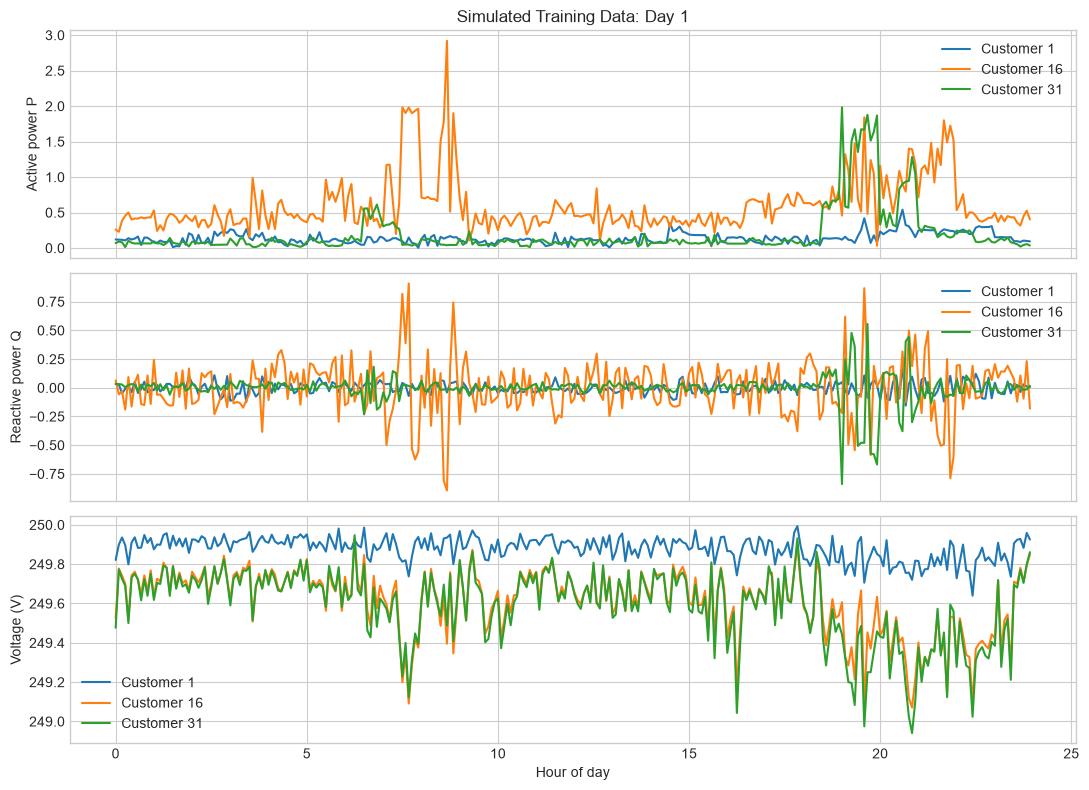

In [9]:
DAY_TO_PLOT = 1
CUSTOMERS_TO_PLOT = [1, 16, 31]

# Separate the alternating P/Q columns; keep all time steps.
P_tr = PQ_tr[:, 0::2]  # Columns 0, 2, 4, ... contain P.
Q_tr = PQ_tr[:, 1::2]  # Columns 1, 3, 5, ... contain Q.

# Check that the chosen day and customers exist.
available_days = len(PQ_tr) // STEPS_PER_DAY
if DAY_TO_PLOT < 1 or DAY_TO_PLOT > available_days:
    raise ValueError(f"Choose DAY_TO_PLOT between 1 and {available_days}.")
if not CUSTOMERS_TO_PLOT:
    raise ValueError("Choose at least one customer.")
for customer in CUSTOMERS_TO_PLOT:
    if customer < 1 or customer > C:
        raise ValueError(f"Choose customer numbers between 1 and {C}.")

# Select this day's rows and convert the time axis to hours.
start = (DAY_TO_PLOT - 1) * STEPS_PER_DAY
end = start + STEPS_PER_DAY
hours = np.arange(STEPS_PER_DAY) * MINUTES_PER_STEP / 60

# Draw one P, Q and V curve for each selected customer.
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for customer in CUSTOMERS_TO_PLOT:
    column = customer - 1
    axes[0].plot(hours, P_tr[start:end, column], label=f"Customer {customer}")
    axes[1].plot(hours, Q_tr[start:end, column], label=f"Customer {customer}")
    axes[2].plot(hours, V_tr[start:end, column], label=f"Customer {customer}")

axes[0].set_ylabel("Active power P")
axes[1].set_ylabel("Reactive power Q")
axes[2].set_ylabel("Voltage (V)")
axes[0].set_title(f"Simulated Training Data: Day {DAY_TO_PLOT}")
axes[2].set_xlabel("Hour of day")
for axis in axes:
    axis.legend(loc="best")
plt.tight_layout()
plt.show()


### 2.4 Definition of Functions

A **function** groups code for a task we will repeat. Run each definition once; its task is performed when the function is called. Section 2.5 uses these functions to carry out the experiment.


#### 2.4.1 def <font color=blue>build_model</font> (in_dim, out_dim, config, seed=SEED)

Creates a **new, untrained network**. `in_dim` and `out_dim` set the input/output counts; `config` contains the model settings; `seed` controls initialisation.

A **neuron** combines incoming values using adjustable multipliers (**weights**) and an offset (**bias**). A hidden layer sits between the inputs and outputs. These quantities are learned numbers, not physical feeder parameters.

- `Sequential` connects the layers in order: **62 inputs → 93 or 155 hidden neurons → 31 outputs**.
- The hidden layer uses `tanh` to represent nonlinear relationships. The final layer is linear, so scaled voltage estimates are not restricted to a fixed range.
- `compile()` selects **Adam**, the algorithm that adjusts the parameters, and **MSE**, the mean squared prediction error. Training uses scaled voltages.
- **L2 regularisation** discourages large parameters. `kernel_regularizer` applies it to weights; `bias_regularizer` applies it to biases. The added penalty is `(weight_decay / 2) × sum of squared parameters`, explaining the `/ 2` in `L2()`. It does not divide the data.

The example prints the model structure and adjustable-parameter count; it does not train or select a model. Initial weights use the Glorot uniform default and biases start at zero. See [Keras Dense](https://keras.io/api/layers/core_layers/dense/) and [regularizers](https://keras.io/api/layers/regularizers/) for the arguments.


In [10]:
def build_model(in_dim, out_dim, config, seed=SEED):
    """Create a fresh Keras network for one training run."""
    keras.backend.clear_session()
    set_seed(seed)
    l2_penalty = keras.regularizers.L2(config["weight_decay"] / 2)

    model = keras.Sequential([
        keras.Input(shape=(in_dim,)),
        keras.layers.Dense(
            int(config["hidden_neurons"]),
            activation=config["activation"],
            kernel_regularizer=l2_penalty,
            bias_regularizer=l2_penalty,
        ),
        keras.layers.Dense(
            out_dim,
            activation="linear",
            kernel_regularizer=l2_penalty,
            bias_regularizer=l2_penalty,
        ),
    ], name="lv_voltage_estimator")

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=config["lr"], epsilon=1e-8
        ),
        loss="mse",
    )
    return model

example_config = {
    "hidden_neurons": 93,
    "activation": "tanh",
    "lr": 1e-3,
    "weight_decay": 1e-5,
}
example_model = build_model(2 * C, C, example_config)
example_model.summary()


Model: "lv_voltage_estimator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 93)             │         5,859 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         2,914 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,773 (34.27 KB)

 Trainable params: 8,773 (34.27 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.4.2 def <font color=blue>blocked_kfold_indices</font> (n_instances, k=3)

**K-fold validation** compares settings by training K fresh models, each checked on a different part of the training dataset. This function splits `n_instances` row indices into `k` consecutive blocks without shuffling.

| Fold when K = 3 | Block 1 | Block 2 | Block 3 |
|---|---|---|---|
| 1 | Validate | Train | Train |
| 2 | Train | Validate | Train |
| 3 | Train | Train | Validate |

It returns training and validation indices for each fold. Test data are not included.

This split is for same-time voltage estimation, not future forecasting: training blocks may lie before or after the validation block. There is no time gap, so neighbouring blocks may still be correlated.


In [11]:
def blocked_kfold_indices(n_instances, k=3):
    """Create k adjacent validation blocks without shuffling time."""
    if not 2 <= k <= n_instances:
        raise ValueError("k must be between 2 and the number of rows.")
    fold_sizes = [n_instances // k] * k
    for i in range(n_instances % k):
        fold_sizes[i] += 1

    all_indices = np.arange(n_instances)
    folds = []
    start = 0
    for fold_size in fold_sizes:
        end = start + fold_size
        validation_indices = all_indices[start:end]
        training_indices = np.concatenate(
            [all_indices[:start], all_indices[end:]]
        )
        folds.append((training_indices, validation_indices))
        start = end
    return folds


#### 2.4.3 def <font color=blue>prepare_fold</font> (PQ, V, training_indices, validation_indices)

**Scaling** puts columns on comparable numerical ranges. For a non-constant column, its training minimum becomes 0 and maximum becomes 1. This is **not a per-unit conversion** using a voltage or power base.

For the supplied row indices, this function:

- Uses separate [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) objects for P/Q and V.
- Calls `fit()` on training rows to learn each column's range, then `transform()` on both training and validation rows.
- Returns scaled inputs (`X_train`, `X_val`), scaled voltages (`Y_train`, `Y_val`) and both scalers.

For a 240–250 V training range, 245 V becomes 0.5 and a validation value of 251 V becomes 1.1. Validation values may legitimately lie outside `[0, 1]`.

<font color='red'>**<u>Note</u>:**</font> Fit scalers on each fold's training rows only. Fitting them on validation or test data would pass information from the data being checked into model preparation.


In [12]:
def prepare_fold(PQ, V, training_indices, validation_indices):
    """Fit scalers on one fold's training blocks and transform both parts."""
    PQ_train, PQ_val = PQ[training_indices], PQ[validation_indices]
    V_train, V_val = V[training_indices], V[validation_indices]

    input_scaler = MinMaxScaler().fit(PQ_train)
    output_scaler = MinMaxScaler().fit(V_train)

    X_train = input_scaler.transform(PQ_train).astype(np.float32)
    Y_train = output_scaler.transform(V_train).astype(np.float32)
    X_val = input_scaler.transform(PQ_val).astype(np.float32)
    Y_val = output_scaler.transform(V_val).astype(np.float32)

    return X_train, Y_train, X_val, Y_val, input_scaler, output_scaler


#### 2.4.4 def <font color=blue>train_model</font> (model, X_train, Y_train, config)

Calls `fit()` to train `model` using scaled inputs `X_train`, targets `Y_train` and the settings in `config`.

- **Batch size:** rows used for one parameter update.
- **Epoch:** one pass through all training rows. More epochs do not necessarily improve performance on new data.
- `shuffle=True`: changes training-row order, not fold membership.
- `verbose=0`: hides per-epoch messages; the search prints comparison summaries.

The returned `history` records training loss, which includes L2 and is not RMSE in volts. Each candidate completes its specified epochs without early stopping because epoch count is one of the settings compared. See the [Keras training API](https://keras.io/api/models/model_training_apis/).


In [13]:
def train_model(model, X_train, Y_train, config):
    """Train for the specified number of epochs."""
    history = model.fit(
        X_train,
        Y_train,
        batch_size=int(config["batch_size"]),
        epochs=int(config["epochs"]),
        shuffle=True,
        verbose=0,  # The search prints one summary for each configuration.
    )
    return history


#### 2.4.5 def <font color=blue>predict_unscaled</font> (model, X_scaled, output_scaler)

Uses the trained `model` to predict from `X_scaled`, then applies `output_scaler.inverse_transform()` to return estimates **in volts**.

Use the input and voltage scalers fitted for that model. The result has one row per time step and one column per customer. Prediction does not change the model's weights.


In [14]:
def predict_unscaled(model, X_scaled, output_scaler):
    """Convert model predictions back to volts."""
    scaled_prediction = model.predict(X_scaled, verbose=0)
    return output_scaler.inverse_transform(scaled_prediction)


#### 2.4.6 def <font color=blue>evaluate_config</font> (config, PQ, V, k=3, seed=SEED)

Checks one `config` using the training dataset `PQ`, `V`, with `k` folds and the specified `seed`.

1. Prepare one fold's data and training-only scalers.
2. Build a fresh model and train on that fold's training rows.
3. Predict validation voltages and restore volts.
4. Calculate **RMSE**: square the errors, average them, then take the square root. Lower RMSE means closer estimates, with larger errors receiving more weight.

Returns each fold's RMSE, their mean (`RMSE_kfold`), standard deviation (`RMSE_std`) and elapsed time. The mean ranks candidates; the standard deviation describes differences between blocks, not a confidence interval.


In [15]:
def evaluate_config(config, PQ, V, k=3, seed=SEED):
    """Evaluate one configuration on all blocked folds."""
    if "hidden_neurons" in config:
        hidden_neurons = int(config["hidden_neurons"])
    else:
        hidden_neurons = round(config["hidden_multiplier"] * V.shape[1])
    fold_rmse = []
    start_time = time.time()

    for training_indices, validation_indices in blocked_kfold_indices(len(PQ), k):
        X_train, Y_train, X_val, _, _, output_scaler = prepare_fold(
            PQ, V, training_indices, validation_indices
        )

        model = build_model(
            X_train.shape[1], Y_train.shape[1],
            {**config, "hidden_neurons": hidden_neurons}, seed=seed,
        )
        train_model(model, X_train, Y_train, config)

        V_val_estimated = predict_unscaled(model, X_val, output_scaler)
        V_val = V[validation_indices]
        fold_rmse.append(
            float(np.sqrt(np.mean((V_val - V_val_estimated) ** 2)))
        )

    return {
        "hidden_neurons": hidden_neurons,
        **{f"fold_{i}_RMSE": value for i, value in enumerate(fold_rmse, 1)},
        "RMSE_kfold": float(np.mean(fold_rmse)),
        "RMSE_std": float(np.std(fold_rmse)),
        "train_time_s": float(time.time() - start_time),
    }


#### 2.4.7 def <font color=blue>run_grid_search</font> (PQ, V, search_space, k=3, seed=SEED)

A **hyperparameter** is a setting chosen before training, such as layer size or learning rate. Weights and biases, in contrast, are learned during training.

This function tries every combination in `search_space`, calls `evaluate_config()` using the same folds and seed, and returns a table sorted by mean validation RMSE. Defining it does not start the search.


In [16]:
def run_grid_search(PQ, V, search_space, k=3, seed=SEED):
    '''Compare all candidate settings using training-data folds only.'''
    configurations = [
        dict(zip(search_space, values))
        for values in itertools.product(*search_space.values())
    ]
    rows = []
    for number, config in enumerate(configurations, start=1):
        scores = evaluate_config(config, PQ, V, k=k, seed=seed)
        rows.append({**config, **scores})
        print(f"Configuration {number}/{len(configurations)}: "
              f"mean validation RMSE = {scores['RMSE_kfold']:.6f} V")
    return pd.DataFrame(rows).sort_values("RMSE_kfold", kind="stable").reset_index(drop=True)


#### 2.4.8 def <font color=blue>run_seed_search</font> (PQ, V, config, seeds, k=3)

Keeps `config` fixed and compares the numbers in `seeds` on the same folds. Different seeds change the initial weights and training-row order.

Returns a table sorted by mean validation RMSE. We call it after choosing hyperparameters. The selected seed helps repeat this experiment; it is not a universally best seed for other data or training budgets.


In [17]:
def run_seed_search(PQ, V, config, seeds, k=3):
    '''Compare random seeds without using the test dataset.'''
    rows = []
    for seed in seeds:
        scores = evaluate_config(config, PQ, V, k=k, seed=seed)
        rows.append({"seed": seed, **scores})
        print(f"Seed {seed}: mean validation RMSE = {scores['RMSE_kfold']:.6f} V")
    return pd.DataFrame(rows).sort_values("RMSE_kfold", kind="stable").reset_index(drop=True)


### 2.5 Model Training and Selection

The functions are ready. Compare candidate settings, compare seeds, then train one final model using all training rows. Test data are not used for these decisions.


#### 2.5.1 Set the training mode and candidate hyperparameters

Choose `RUN_MODE`. **Quick** mode uses 20 or 40 epochs for a first complete run; **full** mode uses 1,000 or 2,000. Other candidates are the same.

| Hyperparameter | What it controls | Quick mode | Full mode |
|---|---|---|---|
| Hidden neurons | Hidden-layer size | 93 or 155 | 93 or 155 |
| Activation | Hidden-layer nonlinearity | `tanh` | `tanh` |
| Learning rate | Size of Adam updates | `1e-3` or `1e-4` | `1e-3` or `1e-4` |
| L2 strength | Penalty on large parameters | `1e-4` or `1e-5` | `1e-4` or `1e-5` |
| Batch size | Rows per update | 72 | 72 |
| Epochs | Passes through training data | 20 or 40 | 1,000 or 2,000 |

`1e-3` means 0.001. Hidden sizes are 3 or 5 times the customer count. Two choices each for size, learning rate, L2 and epochs give **16 combinations**. Scaling, one hidden layer, linear output, Adam and MSE stay fixed.

<font color='red'>**<u>Note</u>:**</font> Saved training outputs come from a **local quick-mode run**, not a full-mode or Colab run. Changing modes or candidates requires rerunning Sections 2.5–2.6. Each mode has a separate results folder under `results/tutorial`; rerunning replaces its result tables.

**In Colab**, download the CSV files in `Tutorial_1/results/tutorial/quick` (or `full`) from the Files panel before the runtime ends. Saving the notebook does not save these separate files.


In [18]:
RUN_MODE = "quick"  # Change to "full" for 1,000/2,000 epochs.
if RUN_MODE not in {"quick", "full"}:
    raise ValueError('RUN_MODE must be "quick" or "full".')

SEARCH_SPACE = {
    "hidden_multiplier": [3, 5],
    "activation": ["tanh"],
    "lr": [1e-3, 1e-4],
    "weight_decay": [1e-4, 1e-5],
    "batch_size": [72],
    "epochs": [20, 40] if RUN_MODE == "quick" else [1000, 2000],
}
RESULTS_DIRECTORY = TUTORIAL_DIRECTORY / "results" / "tutorial" / RUN_MODE
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)
n_configurations = int(np.prod([len(values) for values in SEARCH_SPACE.values()]))
print(f"Mode: {RUN_MODE}; candidate epochs: {SEARCH_SPACE['epochs']}")
print(f"Candidate combinations: {n_configurations}")
print("Results folder:", RESULTS_DIRECTORY.relative_to(TUTORIAL_DIRECTORY))


Mode: quick; candidate epochs: [20, 40]
Candidate combinations: 16
Results folder: results\tutorial\quick


#### 2.5.2 Set and inspect the blocked K-fold splits

Set `KFOLDS = 3`. For the supplied data, each validation block has 2,016 rows (7 days); the remaining 4,032 rows (14 days) are used for training.

Check the displayed ranges. They start at 1 for readability, while array indices start at 0. Sixteen candidates × three folds require **48 model fits**.


In [19]:
KFOLDS = 3
folds = blocked_kfold_indices(len(PQ_tr), k=KFOLDS)
fold_summary = pd.DataFrame([
    {
        "Fold": number,
        "Training rows": len(train_idx),
        "Validation rows": len(val_idx),
        "Validation range (1-based)": f"{val_idx[0] + 1}-{val_idx[-1] + 1}",
    }
    for number, (train_idx, val_idx) in enumerate(folds, start=1)
])
display(fold_summary)
print(f"Grid-search model fits: {n_configurations} x {KFOLDS} = {n_configurations * KFOLDS}")


,Fold,Training rows,Validation rows,Validation range (1-based)
0,1,4032,2016,1-2016
1,2,4032,2016,2017-4032
2,3,4032,2016,4033-6048


Grid-search model fits: 16 x 3 = 48


#### 2.5.3 Select hyperparameters using blocked K-fold validation

Run the search. A progress line appears after one configuration's folds finish.

- `RMSE_kfold`: mean validation error in volts; the lowest value ranks first.
- `RMSE_std`: variation between blocks, reported for context.
- The first row supplies `best_config`; the other columns identify its settings.

The table is calculated by this run and saved as `LV_keras_search_results.csv`. These are validation results, not final test results.


In [20]:
search_results = run_grid_search(PQ_tr, V_tr, SEARCH_SPACE, k=KFOLDS, seed=SEED)
search_results.to_csv(RESULTS_DIRECTORY / "LV_keras_search_results.csv", index=False)

columns_to_show = ["hidden_neurons", "activation", "lr", "weight_decay",
                   "batch_size", "epochs", "RMSE_kfold", "RMSE_std"]
display(search_results[columns_to_show].round(6))

best_row = search_results.iloc[0]
best_config = {
    "hidden_neurons": int(best_row["hidden_neurons"]),
    "activation": str(best_row["activation"]),
    "lr": float(best_row["lr"]),
    "weight_decay": float(best_row["weight_decay"]),
    "batch_size": int(best_row["batch_size"]),
    "epochs": int(best_row["epochs"]),
}
print("Selected settings:", best_config)
print(f"Mean validation RMSE: {best_row['RMSE_kfold']:.6f} V")


Configuration 1/16: mean validation RMSE = 0.123115 V


Configuration 2/16: mean validation RMSE = 0.093653 V


Configuration 3/16: mean validation RMSE = 0.122379 V


Configuration 4/16: mean validation RMSE = 0.081666 V


Configuration 5/16: mean validation RMSE = 0.314992 V


...

Configuration 14/16: mean validation RMSE = 0.213671 V


Configuration 15/16: mean validation RMSE = 0.298685 V


Configuration 16/16: mean validation RMSE = 0.213570 V


,hidden_neurons,activation,lr,weight_decay,batch_size,epochs,RMSE_kfold,RMSE_std
0,155,tanh,0.0010,0.00001,72,40,0.075256,0.003544
1,93,tanh,0.0010,0.00001,72,40,0.081666,0.004465
2,155,tanh,0.0010,0.00010,72,40,0.088135,0.003871
3,93,tanh,0.0010,0.00010,72,40,0.093653,0.005698
4,155,tanh,0.0010,0.00001,72,20,0.106591,0.005095
5,155,tanh,0.0010,0.00010,72,20,0.110390,0.005382
6,93,tanh,0.0010,0.00001,72,20,0.122379,0.004804
7,93,tanh,0.0010,0.00010,72,20,0.123115,0.004773
8,155,tanh,0.0001,0.00001,72,40,0.213570,0.003469
9,155,tanh,0.0001,0.00010,72,40,0.213671,0.003793


Selected settings: {'hidden_neurons': 155, 'activation': 'tanh', 'lr': 0.001, 'weight_decay': 1e-05, 'batch_size': 72, 'epochs': 40}
Mean validation RMSE: 0.075256 V


#### 2.5.4 Compare and select random seeds

Keep `best_config` fixed and compare seeds **0–9** using the same three folds (**30 fits**). The first row supplies `selected_seed`.

Look at the spread of validation errors as well as the best row: a large spread indicates sensitivity to random starting conditions. No test voltages are used here.


In [21]:
SEEDS_TO_TRY = list(range(10))
seed_results = run_seed_search(PQ_tr, V_tr, best_config, SEEDS_TO_TRY, k=KFOLDS)
selected_seed = int(seed_results.iloc[0]["seed"])
display(seed_results[["seed", "RMSE_kfold", "RMSE_std"]].round(6))
seed_results.to_csv(RESULTS_DIRECTORY / "LV_keras_seed_results.csv", index=False)
print(f"Selected seed: {selected_seed}")


Seed 0: mean validation RMSE = 0.075048 V


Seed 1: mean validation RMSE = 0.069666 V


Seed 2: mean validation RMSE = 0.076155 V


Seed 3: mean validation RMSE = 0.073398 V


Seed 4: mean validation RMSE = 0.075152 V


...

Seed 7: mean validation RMSE = 0.074835 V


Seed 8: mean validation RMSE = 0.072435 V


Seed 9: mean validation RMSE = 0.073576 V


,seed,RMSE_kfold,RMSE_std
0,1,0.069666,0.003863
1,5,0.070519,0.001058
2,8,0.072435,0.002491
3,3,0.073398,0.000738
4,6,0.073547,0.000961
5,9,0.073576,0.001162
6,7,0.074835,0.002840
7,0,0.075048,0.002759
8,4,0.075152,0.002126
9,2,0.076155,0.002292


Selected seed: 1


#### 2.5.5 Train the final model on all training data

With settings and seed fixed, fit new scalers on **all training rows**, build a fresh model and train it. The temporary fold models are not combined or reused.

The output confirms the selected settings and completed epochs. The standard workflow totals **79 fits**: 48 for settings, 30 for seeds and 1 final fit. Test data remain outside training.


In [22]:
input_scaler_full = MinMaxScaler().fit(PQ_tr)
output_scaler_full = MinMaxScaler().fit(V_tr)
X_train_full = input_scaler_full.transform(PQ_tr).astype(np.float32)
Y_train_full = output_scaler_full.transform(V_tr).astype(np.float32)

FINAL_MODEL = build_model(2 * C, C, best_config, seed=selected_seed)
final_history = train_model(FINAL_MODEL, X_train_full, Y_train_full, best_config)

print(f"Final model trained for {len(final_history.epoch)} epochs.")
print(f"Mode: {RUN_MODE}; hidden neurons: {best_config['hidden_neurons']}; seed: {selected_seed}")
print("No test data were used for training or model selection.")

run_settings = {
    "mode": RUN_MODE, "configuration": best_config, "selected_seed": selected_seed,
    "folds": KFOLDS, "seeds_compared": SEEDS_TO_TRY,
    "training_runs": n_configurations * KFOLDS + len(SEEDS_TO_TRY) * KFOLDS + 1,
    "completed_epochs": len(final_history.epoch),
}
with (RESULTS_DIRECTORY / "LV_keras_run_settings.json").open("w", encoding="utf-8") as settings_file:
    json.dump(run_settings, settings_file, indent=2)


Final model trained for 40 epochs.
Mode: quick; hidden neurons: 155; seed: 1
No test data were used for training or model selection.


### 2.6 Further Analysis of the Results

Apply the fixed model to held-out test data. Inspect overall errors and individual customers: one small average can hide a larger error at a particular location or time.


#### 2.6.1 Evaluate the held-out test data

Transform test P/Q using the **existing training scaler**, predict voltages and restore volts. Do not fit a new scaler on test data.

Define error as **estimate − simulated reference**: positive means overestimation and negative means underestimation.

- **RMSE** gives more weight to larger errors.
- **MAE** is the average absolute error, ignoring its sign.

Both are reported in volts, not percentages, over all test rows and customers. Use this check to report performance, not to retune the model. If test results guide further tuning, an independent assessment requires new untouched data.


In [23]:
X_test_full = input_scaler_full.transform(PQ_te).astype(np.float32)
V_test_estimated = predict_unscaled(FINAL_MODEL, X_test_full, output_scaler_full)
test_error = V_test_estimated - V_te

test_rmse = float(np.sqrt(np.mean(test_error ** 2)))
test_mae = float(np.mean(np.abs(test_error)))
per_customer_rmse = np.sqrt(np.mean(test_error ** 2, axis=0))

test_metrics = pd.DataFrame({
    "Mode": [RUN_MODE, RUN_MODE],
    "Metric": ["Overall RMSE", "Mean absolute error"],
    "Value (V)": [test_rmse, test_mae],
})
display(test_metrics.round(6))
test_metrics.to_csv(RESULTS_DIRECTORY / "LV_keras_test_metrics.csv", index=False)
print("The following plots all use these same test predictions; no model is retrained.")


,Mode,Metric,Value (V)
0,quick,Overall RMSE,0.054894
1,quick,Mean absolute error,0.039941


The following plots all use these same test predictions; no model is retrained.


#### 2.6.2 Compare estimated and simulated voltage profiles

Choose `TEST_DAY_TO_PLOT` and `CUSTOMER_TO_PLOT`.

- **Left:** compare the estimated and simulated voltage curves for that day and customer.
- **Right:** compare all test estimates with their references. Points on the diagonal agree exactly; those above it overestimate and those below it underestimate.

Changing the displayed customer changes only the view, not the trained model.


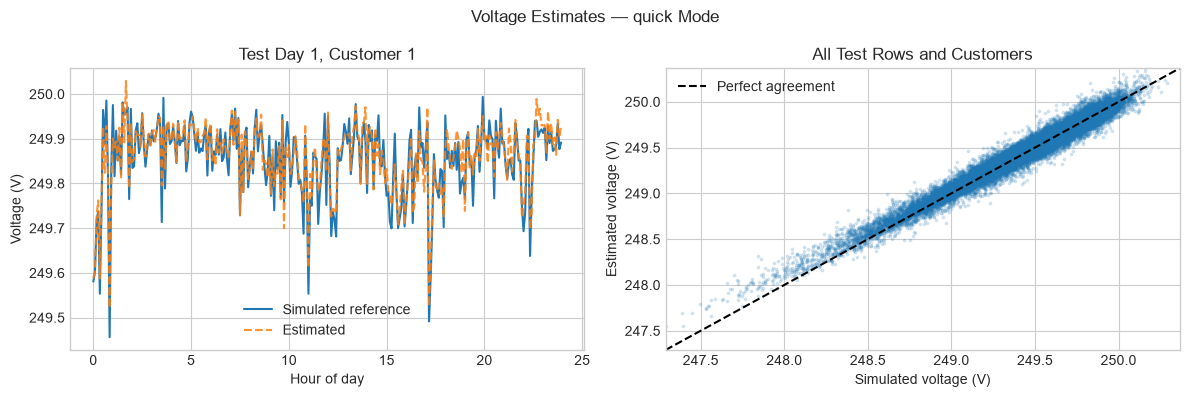

In [24]:
TEST_DAY_TO_PLOT = 1
CUSTOMER_TO_PLOT = 1

test_days = len(V_te) // STEPS_PER_DAY
if not 1 <= TEST_DAY_TO_PLOT <= test_days:
    raise ValueError(f"Choose TEST_DAY_TO_PLOT between 1 and {test_days}.")
if not 1 <= CUSTOMER_TO_PLOT <= C:
    raise ValueError(f"Choose CUSTOMER_TO_PLOT between 1 and {C}.")

test_start = (TEST_DAY_TO_PLOT - 1) * STEPS_PER_DAY
test_end = test_start + STEPS_PER_DAY
customer_index = CUSTOMER_TO_PLOT - 1
hours = np.arange(STEPS_PER_DAY) * MINUTES_PER_STEP / 60
limits = [min(float(V_te.min()), float(V_test_estimated.min())),
          max(float(V_te.max()), float(V_test_estimated.max()))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hours, V_te[test_start:test_end, customer_index], label="Simulated reference")
axes[0].plot(hours, V_test_estimated[test_start:test_end, customer_index],
             label="Estimated", linestyle="--", alpha=0.85)
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title(f"Test Day {TEST_DAY_TO_PLOT}, Customer {CUSTOMER_TO_PLOT}")
axes[0].legend()

axes[1].scatter(V_te.ravel(), V_test_estimated.ravel(), s=3, alpha=0.15)
axes[1].plot(limits, limits, "k--", label="Perfect agreement")
axes[1].set_xlim(limits)
axes[1].set_ylim(limits)
axes[1].set_xlabel("Simulated voltage (V)")
axes[1].set_ylabel("Estimated voltage (V)")
axes[1].set_title("All Test Rows and Customers")
axes[1].legend()
fig.suptitle(f"Voltage Estimates — {RUN_MODE} Mode")
plt.tight_layout()
plt.show()


#### 2.6.3 Compare voltage errors across customers

Compare each customer's RMSE over the test period. Bars remain in customer order to relate them to Figure 1; the table lists the five largest errors.

A higher bar means a larger **prediction error**, not necessarily a higher voltage.


,Customer,RMSE (V)
17,18,0.085399
16,17,0.077979
20,21,0.076296
25,26,0.075472
18,19,0.073828


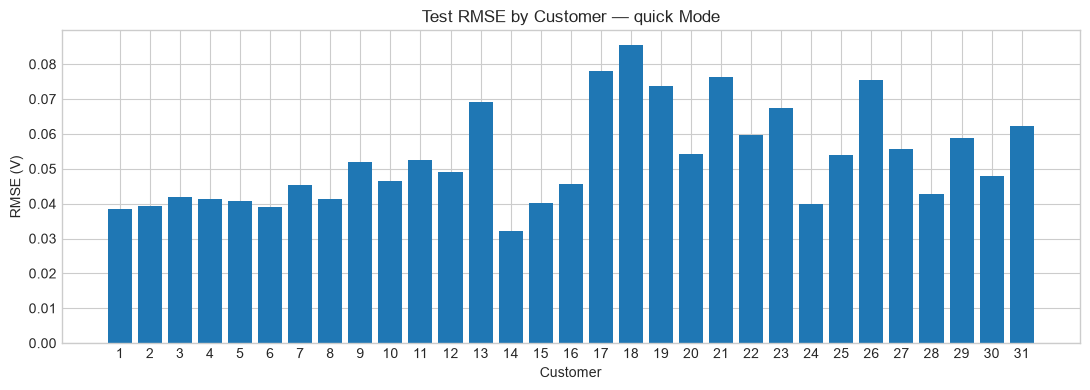

In [25]:
customer_errors = pd.DataFrame({
    "Customer": np.arange(1, C + 1),
    "RMSE (V)": per_customer_rmse,
})
customer_errors.to_csv(RESULTS_DIRECTORY / "LV_keras_per_customer_results.csv", index=False)
display(customer_errors.sort_values("RMSE (V)", ascending=False).head(5).round(6))

fig, axis = plt.subplots(figsize=(11, 4))
axis.bar(customer_errors["Customer"], customer_errors["RMSE (V)"])
axis.set_xlabel("Customer")
axis.set_ylabel("RMSE (V)")
axis.set_title(f"Test RMSE by Customer — {RUN_MODE} Mode")
axis.set_xticks(np.arange(1, C + 1))
plt.tight_layout()
plt.show()


#### 2.6.4 Inspect the customer with the highest error

Inspect the highest-RMSE customer over the full test period. The upper panel compares voltage curves; the lower panel shows the **residual** (estimate − reference).

Look for persistent positive/negative errors or short spikes. The printed mean signed error helps identify a tendency to overestimate or underestimate. These plots locate errors but do not establish their physical cause.

The workflow is complete: **prepare data → validate settings → compare seeds → train final model → assess test voltages**. Report the training mode alongside the errors.


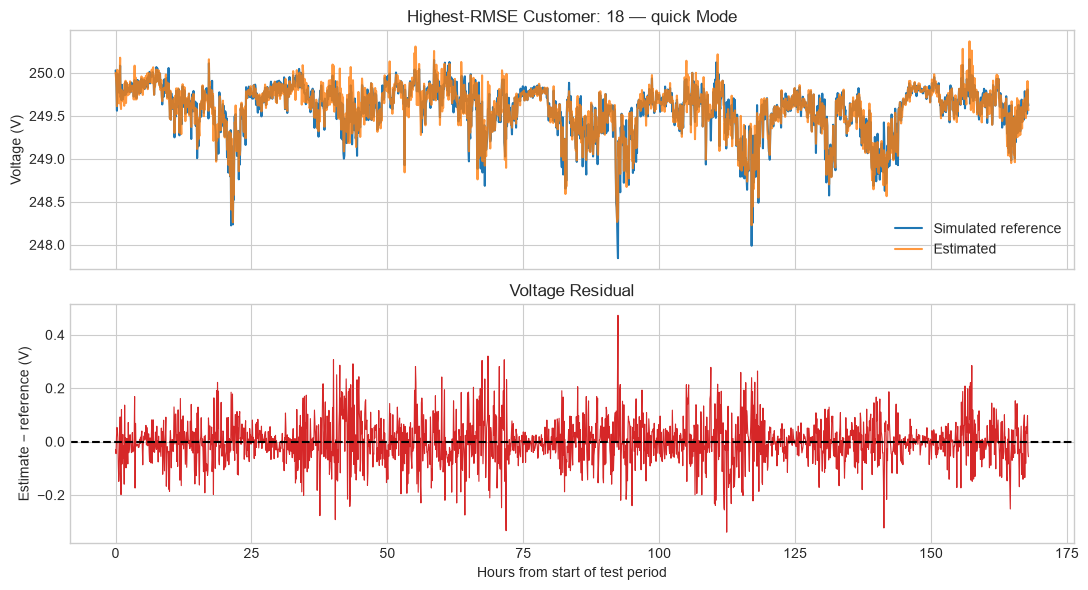

Customer: 18
Customer RMSE: 0.085399 V
Mean signed error: +0.000282 V


In [26]:
worst_customer = int(np.argmax(per_customer_rmse))
test_hours = np.arange(len(V_te)) * MINUTES_PER_STEP / 60

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(test_hours, V_te[:, worst_customer], label="Simulated reference")
axes[0].plot(test_hours, V_test_estimated[:, worst_customer], label="Estimated", alpha=0.8)
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title(f"Highest-RMSE Customer: {worst_customer + 1} — {RUN_MODE} Mode")
axes[0].legend()

axes[1].plot(test_hours, test_error[:, worst_customer], color="tab:red", linewidth=0.8)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Hours from start of test period")
axes[1].set_ylabel("Estimate − reference (V)")
axes[1].set_title("Voltage Residual")
plt.tight_layout()
plt.show()

print(f"Customer: {worst_customer + 1}")
print(f"Customer RMSE: {per_customer_rmse[worst_customer]:.6f} V")
print(f"Mean signed error: {test_error[:, worst_customer].mean():+.6f} V")


## 3. Exercises

Read both exercises before starting. Use the relevant code from **2. Tutorial** in **4. Exercise Workspace**. Complete the tasks in order and show your results using code, tables and plots; no written explanations are required.

Both exercises use the same **simulated P/Q and voltage data** as the tutorial. The aim is to practise training a neural network to estimate customer voltages.

<font color='red'>**<u>Note</u>:**</font> Use only training-data folds to choose network settings and seeds. Use the test data only in **E2.3–E2.4**, after these choices are fixed. This is a classroom reuse of the tutorial's test set, not a new independent test. Do not retune the model using its test results.


### **Exercise 1: Modifying the Neural Network**

Start with the network below. You will first increase the number of hidden neurons, then change the activation function. For every case, use **three blocked folds**, with scalers fitted only on the training rows of each fold, as in **2.4.3**.

| Setting | Starting value |
|---|---|
| Hidden neurons | 93 |
| Hidden-layer activation | `tanh` |
| Learning rate | `1e-3` |
| L2 strength (`weight_decay`) | `1e-5` |
| Batch size | 72 |
| Epochs | 40 |
| Random seed | 42 |

Keep the learning rate, L2 strength, batch size, epochs and seed unchanged throughout Exercise 1. The **40-epoch** budget is a short classroom run, separate from `RUN_MODE`; it is not the tutorial's full training budget.


**E1.1:** Train and validate the network with **93 hidden neurons and `tanh`** using the three blocked folds. Display the mean validation RMSE and its standard deviation, both in **V**.

**E1.2:** Increase the hidden-neuron count to **155**, keeping `tanh` and all other settings unchanged. Repeat E1.1 for this network.

Now change the hidden-layer activation from **`tanh` to `relu`**. This uses the same model-building code; only the activation setting changes.

**E1.3:** Train and validate networks with **93 and 155 hidden neurons using `relu`**. Combine these results with E1.1–E1.2 in one table showing the hidden-neuron count, activation, epochs, mean validation RMSE and standard deviation. Sort the four cases from lowest to highest mean validation RMSE. Store and display the settings of the first case as **`e1_best_config`** for Exercise 2.

> - Reuse `evaluate_config()` from **2.4.6** for each case. It prepares the folds and calls the model-building, training and voltage-prediction functions for you.
> - Keep each configuration together with its returned scores, as in **2.4.7**. Follow **2.5.3** to turn the best row into a configuration dictionary.

Four cases with three folds require **12 training runs**. Do not rerun the earlier cases when assembling the comparison table.


### **Exercise 2: Training and Testing the Voltage Estimator**

Use **`e1_best_config`** from Exercise 1 to complete the training and test procedure. Build a **new model** for the final training run; do not reuse a model already trained on one fold or the tutorial's `FINAL_MODEL`.

Use the following conditions:

- **Network and training settings:** the selected Exercise 1 configuration, including **40 epochs**.
- **Seeds to compare:** **0, 1 and 2**, using the same **three blocked folds**.
- **Final training data:** all rows of `PQ_tr` and `V_tr`.
- **Test inputs and reference voltages:** `PQ_te` and `V_te`.


**E2.1:** Compare seeds **0, 1 and 2** using the selected configuration. Display the mean validation RMSE and its standard deviation for each seed. Store the seed with the lowest mean validation RMSE as **`e2_selected_seed`** and display it together with `e1_best_config`.

**E2.2:** Fit new input and output scalers on **all training rows only**. Build a new network using `e1_best_config` and `e2_selected_seed`, then train it on the scaled training data. Display the model summary and the number of completed epochs.

**E2.3:** Use the trained network to estimate voltages from the **test P/Q**. Apply the fitted input scaler without refitting it, and restore the network outputs to **V**. Display the overall test **RMSE and MAE**, and a table of **RMSE for all 31 customers**.

**E2.4:** Find the customer with the highest test RMSE. Display its customer number and RMSE. For this customer, plot the **simulated and estimated voltages** together, with a second plot showing their difference (**estimate − simulated reference**) over the whole test period.

> - Reuse `run_seed_search()` and **2.5.4–2.5.5** for seed selection and final training.
> - Reuse **2.6.1** for predictions and errors, **2.6.3** for the customer table, and **2.6.4** for the voltage and error plots. Use your exercise model and exercise variables throughout.

Exercise 2 requires **9 seed-validation runs and 1 final training run**. Both exercises together require **22 training runs**.


## 4. Exercise Workspace

Complete **E1.1–E1.3**, then **E2.1–E2.4**. Add the relevant tutorial code below each task label and display the requested results. The comments are starting points, not completed solutions.

In a fresh kernel, run **2.2–2.4** first to load the data and define the functions. You do not need to run **2.5–2.6** again. Use `e1_` and `e2_` variable names to keep your exercise work separate from the tutorial's results.


### Exercise 1: Modifying the Neural Network


In [ ]:
# E1.1 — Starting network: 93 hidden neurons, tanh.
e1_config = {
    "hidden_neurons": 93,
    "activation": "tanh",
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "batch_size": 72,
    "epochs": 40,
}
e1_seed = 42
e1_k = 3
e1_rows = []

# TODO: call evaluate_config() with e1_config, PQ_tr, V_tr, e1_k and e1_seed.
# Display the returned RMSE_kfold and RMSE_std values in volts.
# Save a COPY of this configuration and its scores as one row in e1_rows.


In [ ]:
# E1.2 — Change only the hidden-neuron count to 155.
# TODO: copy e1_config with .copy(), then change "hidden_neurons".
# Evaluate the new configuration on the same three folds with seed 42.
# Display the scores and append this configuration and its scores to e1_rows.


In [ ]:
# E1.3 — Repeat with relu for 93 and 155 hidden neurons.
# TODO: copy e1_config for each case; change hidden_neurons and activation.
# Evaluate each case and append its configuration and scores to e1_rows.

# TODO: create e1_results = pd.DataFrame(e1_rows).
# Sort by "RMSE_kfold" (lowest first) and display:
# hidden_neurons, activation, epochs, RMSE_kfold, RMSE_std.

# TODO: follow Section 2.5.3 to create e1_best_config from the best row.
# Include hidden_neurons, activation, lr, weight_decay, batch_size and epochs.
# Display e1_best_config. Keep it unchanged throughout Exercise 2.


### Exercise 2: Training and Testing the Voltage Estimator


In [ ]:
# E2.1 — Compare seeds using the selected Exercise 1 configuration.
e2_seeds = [0, 1, 2]

# TODO: call run_seed_search() with PQ_tr, V_tr, e1_best_config,
# e2_seeds and k=3. Store the returned table as e2_seed_results.
# Display seed, RMSE_kfold and RMSE_std.
# Store the first row's seed as e2_selected_seed (an integer).
# Display e1_best_config and e2_selected_seed.


In [ ]:
# E2.2 — Train a new model on all training rows.
# TODO: fit e2_input_scaler and e2_output_scaler on PQ_tr and V_tr only.
# Transform the training arrays to obtain e2_X_train and e2_Y_train.
# Use build_model() to create e2_model with e1_best_config and e2_selected_seed.
# Use train_model() and store the returned history as e2_history.
# Display e2_model.summary() and len(e2_history.epoch).


In [ ]:
# E2.3 — Estimate test voltages and calculate errors in volts.
# TODO: transform PQ_te with e2_input_scaler; do not fit a new scaler.
# Use predict_unscaled() with e2_model and e2_output_scaler.
# Store the estimates as e2_V_estimated.
# Calculate e2_error = e2_V_estimated - V_te.
# Display overall RMSE and MAE, then a table of RMSE for customers 1 to 31.


In [ ]:
# E2.4 — Plot the highest-RMSE customer's voltage estimates.
# TODO: find the customer with the highest RMSE from E2.3.
# Display its customer number (array index + 1) and RMSE in volts.
# Adapt Section 2.6.4 using e2_V_estimated and e2_error.
# Plot simulated and estimated voltages over the full test period.
# Below them, plot estimate - simulated reference, with a zero-error line.
